In [1]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.0 MB/s eta 0:00:00


In [2]:
!pip install -U tensorflow transformers Sastrawi nltk scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 16.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: scikit-learn
    Found existing installation: sciki

In [3]:
pip install --no-cache-dir tensorflow transformers

In [4]:
# ==============================
# LIBRARY UMUM
# ==============================
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# NLP PREPROCESSING
# ==============================
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('stopwords')

# ==============================
# MACHINE LEARNING
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# TENSORFLOW (LSTM & GRU)
# ==============================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# PYTORCH (INDOBERT)
# ==============================
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader

print("Semua library berhasil diimport 🚀")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Semua library berhasil diimport 🚀


In [5]:
df = pd.read_csv("indonesian_news.csv")
df.head()

,date,url,title,category
0,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Kemnaker Awasi TKA di Meikarta,finance
1,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,BNI Digitalkan BNI Java Jazz 2020,finance
2,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Terbang ke Australia, Edhy Prabowo Mau Genjot ...",finance
3,02/26/2020,https://finance.detik.com/moneter/d-4916133/oj...,OJK Siapkan Stimulus Ekonomi Antisipasi Dampak...,finance
4,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Saran Buat Anies-RK yang Mangkir Rapat Banjir ...,finance


In [6]:
df.info()
df['category'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91017 entries, 0 to 91016
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      91017 non-null  object
 1   url       91017 non-null  object
 2   title     91017 non-null  object
 3   category  91017 non-null  object
dtypes: object(4)
memory usage: 2.8+ MB


,count
category,
news,32360
hot,16330
finance,14168
travel,6466
inet,5640
health,4919
oto,4383
food,4315
sport,2436


In [7]:
selected_classes = ['hot','finance','travel','inet','health']

df = df[df['category'].isin(selected_classes)]
df['category'].value_counts()

,count
category,
hot,16330
finance,14168
travel,6466
inet,5640
health,4919


In [8]:
print("Jumlah missing value:")
print(df.isnull().sum())

Jumlah missing value:
date        0
url         0
title       0
category    0
dtype: int64


In [9]:
print(df.columns)

Index(['date', 'url', 'title', 'category'], dtype='object')


In [10]:
# ==============================
# DATA CLEANING FINAL
# ==============================

# 1️⃣ Hapus missing value
df = df.dropna(subset=['title','category'])
print("Shape setelah hapus missing:", df.shape)

# 2️⃣ Hapus duplikat berita (judul sama)
df = df.drop_duplicates(subset=['title'])
print("Shape setelah hapus duplikat:", df.shape)

# 3️⃣ Filter hanya 5 kelas target
selected_classes = ['hot','finance','travel','inet','health']
df = df[df['category'].isin(selected_classes)]

print("\nJumlah data per kelas:")
print(df['category'].value_counts())

# 4️⃣ Reset index biar rapi
df = df.reset_index(drop=True)

df.head()

Shape setelah hapus missing: (47523, 4)
Shape setelah hapus duplikat: (47439, 4)

Jumlah data per kelas:
category
hot        16300
finance    14141
travel      6455
inet        5629
health      4914
Name: count, dtype: int64


,date,url,title,category
0,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Kemnaker Awasi TKA di Meikarta,finance
1,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,BNI Digitalkan BNI Java Jazz 2020,finance
2,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Terbang ke Australia, Edhy Prabowo Mau Genjot ...",finance
3,02/26/2020,https://finance.detik.com/moneter/d-4916133/oj...,OJK Siapkan Stimulus Ekonomi Antisipasi Dampak...,finance
4,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Saran Buat Anies-RK yang Mangkir Rapat Banjir ...,finance


In [11]:
# stopword Indonesia
stop_words = set(stopwords.words('indonesian'))

# stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

print("Stopword & Stemmer siap")

Stopword & Stemmer siap


In [12]:
def clean_text(text):

    # huruf kecil
    text = text.lower()

    # hapus url
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus spasi berlebih
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # tokenisasi
    tokens = text.split()

    # hapus stopword
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [13]:
df['clean_title'] = df['title'].apply(clean_text)

In [14]:
df[['title','clean_title']].head(10)

,title,clean_title
0,Kemnaker Awasi TKA di Meikarta,kemnaker awasi tka meikarta
1,BNI Digitalkan BNI Java Jazz 2020,bni digitalkan bni java jazz
2,"Terbang ke Australia, Edhy Prabowo Mau Genjot ...",terbang australia edhy prabowo genjot budi day...
3,OJK Siapkan Stimulus Ekonomi Antisipasi Dampak...,ojk siapkan stimulus ekonomi antisipasi dampak...
4,Saran Buat Anies-RK yang Mangkir Rapat Banjir ...,saran aniesrk mangkir rapat banjir dpr
5,RI Bakal Punya Destinasi Wisata Sejarah Islam ...,ri destinasi wisata sejarah islam ancol
6,Cara Biar Nggak Tertipu Travel Umrah Abal-abal...,biar nggak tertipu travel umrah abalabal first...
7,"DPR Kritik Cara Anies Atasi Banjir, Pesan Kera...",dpr kritik anies atasi banjir pesan keras eric...
8,Jadi Korban Gagal Bayar Asuransi? Bisa Mengadu...,korban gagal bayar asuransi mengadu
9,Erick Thohir: BUMN Bukan Badan Usaha Milik Nen...,erick thohir bumn badan usaha milik nenek lu


In [15]:
# ==============================
# TOKENIZATION
# ==============================

max_words = 20000

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_title'])

sequences = tokenizer.texts_to_sequences(df['clean_title'])

print("Contoh sequence:")
print(sequences[:5])

Contoh sequence:
[[3687, 1871, 3865, 3688], [571, 14651, 571, 1399, 1112], [341, 391, 823, 602, 765, 1071, 634, 1872], [310, 175, 1371, 31, 775, 138, 2], [660, 8149, 5896, 377, 32, 61]]


In [16]:
# ==============================
# PADDING
# ==============================

max_len = 30

X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print("Shape X:", X.shape)

Shape X: (47439, 30)


In [17]:
# ==============================
# LABEL ENCODING
# ==============================

encoder = LabelEncoder()
y = encoder.fit_transform(df['category'])

print("Contoh label:")
print(y[:10])

Contoh label:
[0 0 0 0 0 0 0 0 0 0]


In [18]:
# ==============================
# SPLIT DATA
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (37951, 30)
Test : (9488, 30)


In [19]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Input

model_lstm = Sequential()

# FIX UTAMA
model_lstm.add(Input(shape=(30,)))

# Embedding
model_lstm.add(Embedding(input_dim=20000, output_dim=128))

# LSTM
model_lstm.add(LSTM(128))

# Dropout
model_lstm.add(Dropout(0.3))

# Output
model_lstm.add(Dense(5, activation='softmax'))

# Compile
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,692,229 (10.27 MB)

 Trainable params: 2,692,229 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ==============================
# TRAINING
# ==============================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5970 - loss: 0.9913 - val_accuracy: 0.8386 - val_loss: 0.4904
Epoch 2/5
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8891 - loss: 0.3443 - val_accuracy: 0.8741 - val_loss: 0.3863
Epoch 3/5
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9401 - loss: 0.1964 - val_accuracy: 0.8832 - val_loss: 0.3790
Epoch 4/5
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9609 - loss: 0.1335 - val_accuracy: 0.8770 - val_loss: 0.4336
Epoch 5/5
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9721 - loss: 0.0997 - val_accuracy: 0.8793 - val_loss: 0.4445


In [21]:

# EVALUASI


loss, acc = model_lstm.evaluate(X_test, y_test)

print("Akurasi LSTM:", acc)

297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8793 - loss: 0.3806
Akurasi LSTM: 0.879321277141571


297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


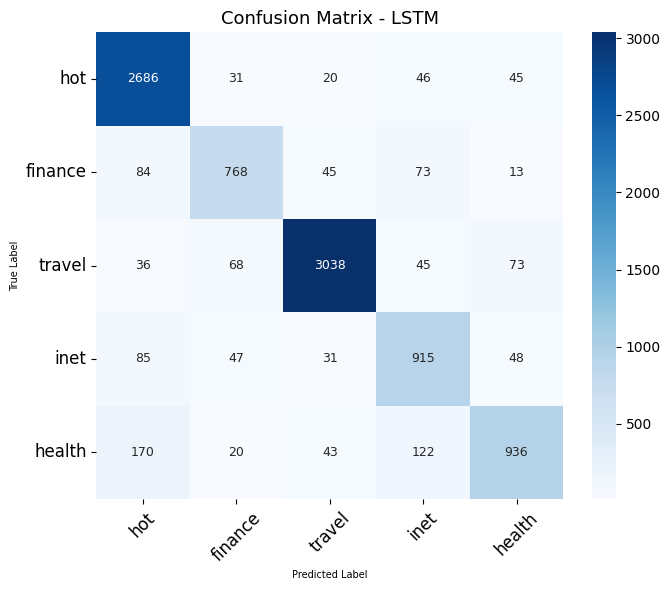

<Figure size 640x480 with 0 Axes>

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2828
           1       0.82      0.78      0.80       983
           2       0.96      0.93      0.94      3260
           3       0.76      0.81      0.79      1126
           4       0.84      0.73      0.78      1291

    accuracy                           0.88      9488
   macro avg       0.85      0.84      0.84      9488
weighted avg       0.88      0.88      0.88      9488



In [22]:
# ==============================
# PREDIKSI
# ==============================

y_pred = model_lstm.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

# membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ['hot', 'finance', 'travel', 'inet', 'health']

plt.figure(figsize=(7,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            annot_kws={"size":9})  # angka lebih besar

plt.xlabel("Predicted Label", fontsize=7)
plt.ylabel("True Label", fontsize=7)
plt.title("Confusion Matrix - LSTM", fontsize=13)

plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()
# simpan kualitas tinggi
plt.savefig("confusion_matrix_lstm.png", dpi=300)

plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

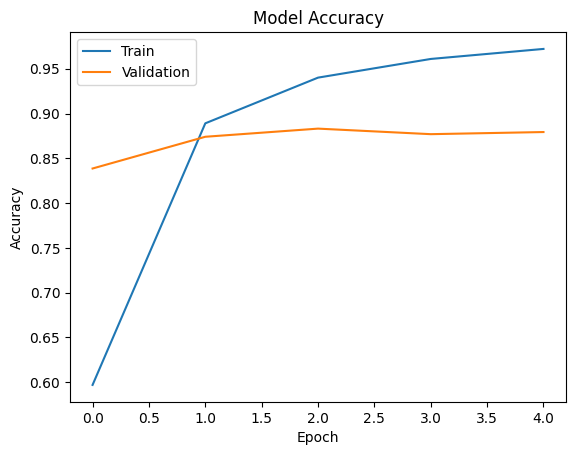

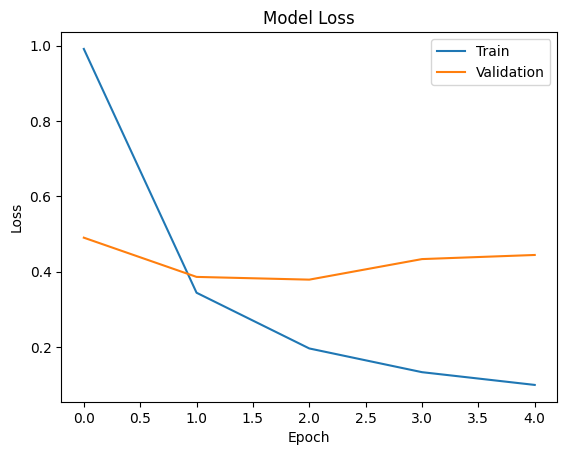

In [23]:

# GRAFIK


plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [24]:
from keras.models import Sequential
from keras.layers import Embedding, GRU, Dense, Dropout, Input

model_gru = Sequential()

model_gru.add(Input(shape=(30,)))  # FIX utama
model_gru.add(Embedding(input_dim=20000, output_dim=128))

model_gru.add(GRU(128, return_sequences=True))
model_gru.add(Dropout(0.5))

model_gru.add(GRU(64))
model_gru.add(Dropout(0.5))

model_gru.add(Dense(64, activation='relu'))
model_gru.add(Dense(5, activation='softmax'))

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 30, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,700,805 (10.30 MB)

 Trainable params: 2,700,805 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3392 - loss: 1.4928 - val_accuracy: 0.3438 - val_loss: 1.4881
Epoch 2/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6511 - loss: 0.8279 - val_accuracy: 0.7987 - val_loss: 0.5021
Epoch 3/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8947 - loss: 0.3148 - val_accuracy: 0.8904 - val_loss: 0.3495
Epoch 4/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9513 - loss: 0.1604 - val_accuracy: 0.8925 - val_loss: 0.3743
Epoch 5/5
534/534 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9691 - loss: 0.1038 - val_accuracy: 0.8930 - val_loss: 0.4064


In [26]:
loss_gru, acc_gru = model_gru.evaluate(X_test, y_test)

print("Akurasi GRU:", acc_gru)

297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8894 - loss: 0.3523
Akurasi GRU: 0.8894392848014832


297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report GRU:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      2828
           1       0.75      0.87      0.81       983
           2       0.95      0.94      0.95      3260
           3       0.81      0.77      0.79      1126
           4       0.87      0.80      0.83      1291

    accuracy                           0.89      9488
   macro avg       0.86      0.86      0.86      9488
weighted avg       0.89      0.89      0.89      9488



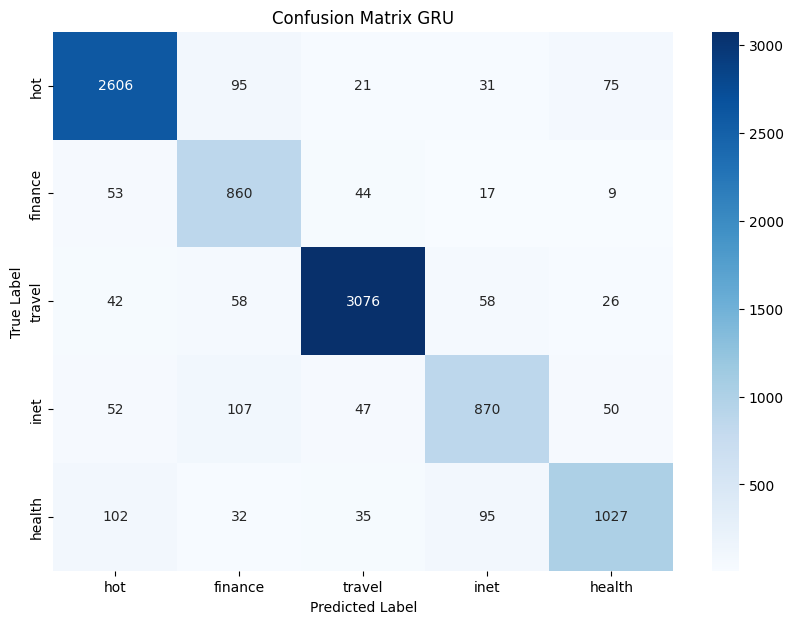

In [29]:

# ==============================
# PREDIKSI GRU
# ==============================

y_pred_gru = model_gru.predict(X_test)
y_pred_gru = np.argmax(y_pred_gru, axis=1)

# Classification report
print("Classification Report GRU:")
print(classification_report(y_test, y_pred_gru))
y_test_1d = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

# 3. BUAT CONFUSION MATRIX
cm = confusion_matrix(y_test_1d, y_pred_gru)

# 4. PLOTTING HEATMAP
plt.figure(figsize=(10,7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['hot','finance','travel','inet','health'],
    yticklabels=['hot','finance','travel','inet','health']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix GRU")

plt.show()

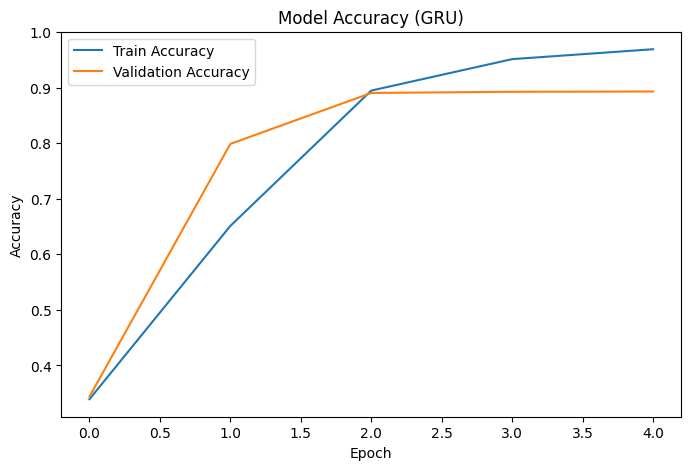

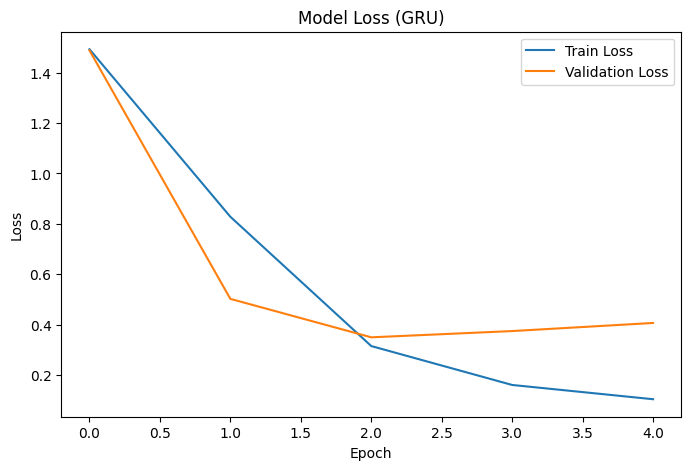

In [30]:
# ==============================
# GRAFIK ACCURACY
# ==============================

plt.figure(figsize=(8,5))

plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy (GRU)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# ==============================
# GRAFIK LOSS
# ==============================

plt.figure(figsize=(8,5))

plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('Model Loss (GRU)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [31]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [32]:
import torch
from torch.utils.data import Dataset

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])   # ✅ aman (numpy/pandas)
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [33]:
from torch.utils.data import DataLoader

train_dataset = NewsDataset(X_train, y_train, tokenizer)
test_dataset  = NewsDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [34]:
from transformers import AutoModelForSequenceClassification

model_bert = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=5
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
print(df['category'].value_counts())

category
hot        16300
finance    14141
travel      6455
inet        5629
health      4914
Name: count, dtype: int64


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [37]:
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=1e-5)

In [38]:
print(df['category'].unique())

['finance' 'health' 'hot' 'inet' 'travel']


In [39]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):
    model_bert.train()
    total_loss = 0

    loop = tqdm(train_loader, leave=True)

    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()

    print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

100%|██████████| 2372/2372 [13:42<00:00,  2.88it/s]


Epoch 1 Loss: 0.7809252368214008


100%|██████████| 2372/2372 [13:41<00:00,  2.89it/s]


Epoch 2 Loss: 0.45015654797723886


100%|██████████| 2372/2372 [13:40<00:00,  2.89it/s]


Epoch 3 Loss: 0.34953134803770464


100%|██████████| 2372/2372 [13:41<00:00,  2.89it/s]


Epoch 4 Loss: 0.2763012607963159


100%|██████████| 2372/2372 [13:40<00:00,  2.89it/s]

Epoch 5 Loss: 0.22301958313621706


In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_bert.eval()

y_pred = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

In [41]:
print("Akurasi IndoBERT:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Akurasi IndoBERT: 0.8932335581787522
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2828
           1       0.83      0.87      0.85       983
           2       0.94      0.95      0.94      3260
           3       0.83      0.74      0.78      1126
           4       0.83      0.78      0.80      1291

    accuracy                           0.89      9488
   macro avg       0.87      0.86      0.86      9488
weighted avg       0.89      0.89      0.89      9488



In [42]:
print(df['category'].unique())

['finance' 'health' 'hot' 'inet' 'travel']


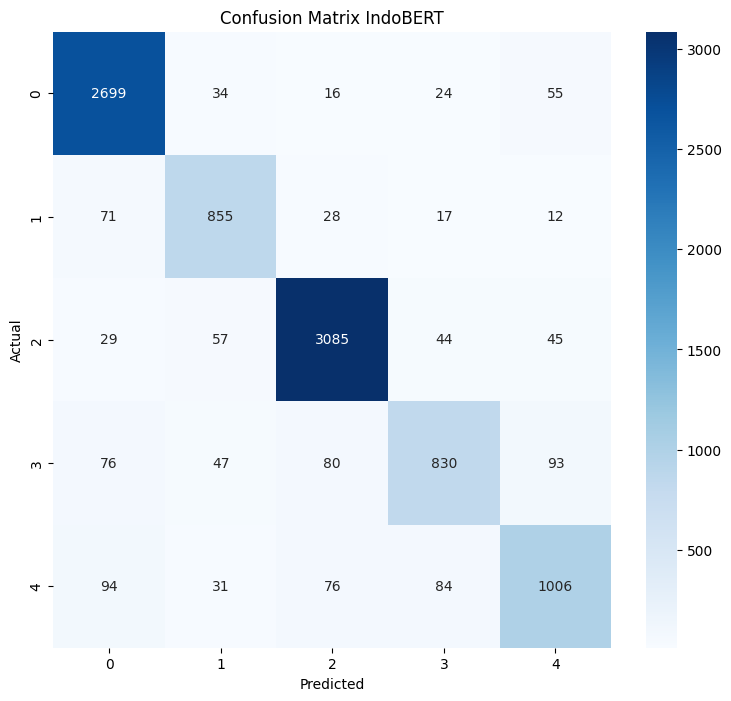

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix IndoBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
# ==============================
# HASIL EVALUASI MODEL (ISI SESUAI OUTPUT NOTEBOOK)
# ==============================

model_names = ["CNN-BiLSTM", "CNN-BiGRU", "IndoBERT"]

accuracy  = [0.8793, 0.8894, 0.8932]
precision = [0.85,   0.86,   0.87]
recall    = [0.84,   0.86,   0.86]
f1_score  = [0.84,   0.86,   0.86]

In [49]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN-BiLSTM,0.8793,0.85,0.84,0.84
1,CNN-BiGRU,0.8894,0.86,0.86,0.86
2,IndoBERT,0.8932,0.87,0.86,0.86


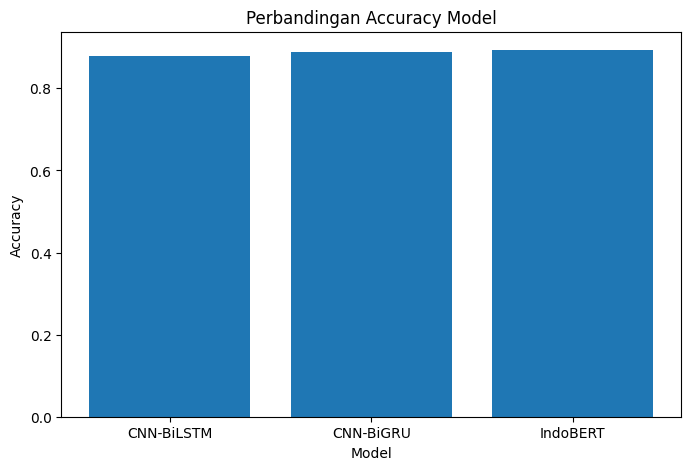

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracy)
plt.title("Perbandingan Accuracy Model")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

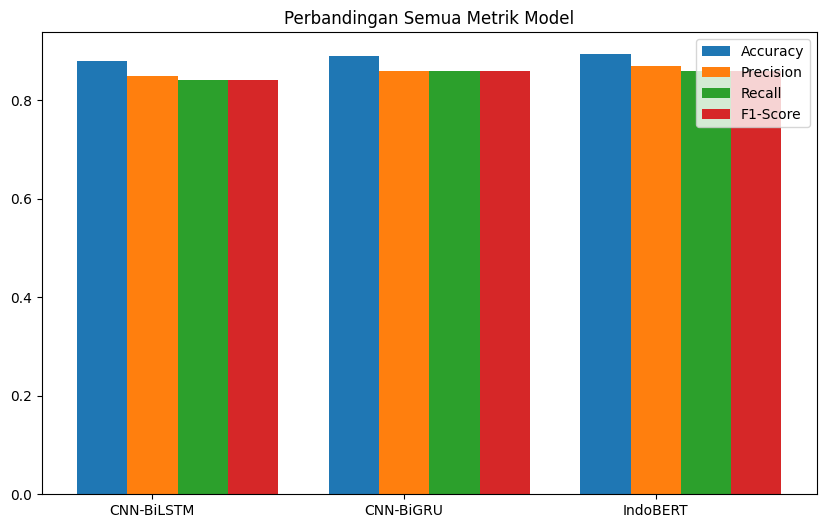

In [51]:
import numpy as np

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - width, accuracy,  width, label='Accuracy')
plt.bar(x,         precision, width, label='Precision')
plt.bar(x + width, recall,    width, label='Recall')
plt.bar(x + 2*width, f1_score, width, label='F1-Score')

plt.xticks(x, model_names)
plt.title("Perbandingan Semua Metrik Model")
plt.legend()
plt.show()

In [52]:
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print("Model terbaik berdasarkan Accuracy:")
print(best_model)

Model terbaik berdasarkan Accuracy:
Model        IndoBERT
Accuracy       0.8932
Precision        0.87
Recall           0.86
F1-Score         0.86
Name: 2, dtype: object
